# BUSINESS UNDERSTANDING


In [ ]:

# ------------------------------
# BO1 : Réduire les réadmissions des patients diabétiques.
# DSO1 :Prédire avec RLT si un patient sera réadmis dans les 30 jours à partir de ses caractéristiques cliniques et démographiques.
# BO2 : Identifier précocement les patients à haut risque .
# DSO2 :Classer les patients en catégories de risque (élevé, moyen, faible).

#{option BO 3}
# BO3 :Réduire la durée de séjour pour une gestion efficace de l’hôpital .
# DSO3 : Prédire le moment optimal de sortie en se basant sur l’historique du patient et les traitements reçus.
# ------------------------------


# DATA UNDERSTANDING

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Chargement des données
df = pd.read_csv("diabetic_data.csv")

# Structure générale
print("Aperçu du dataset :")
display(df.head())

print("\nDimensions du dataset :", df.shape)

print("\nInformations générales :")
df.info()



Aperçu du dataset :


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6.0,25.0,1.0,1.0,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1.0,1.0,7.0,3.0,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1.0,1.0,7.0,2.0,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1.0,1.0,7.0,2.0,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1.0,1.0,7.0,1.0,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



Dimensions du dataset : (77599, 50)

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77599 entries, 0 to 77598
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   encounter_id              77599 non-null  int64  
 1   patient_nbr               77599 non-null  int64  
 2   race                      77599 non-null  object 
 3   gender                    77598 non-null  object 
 4   age                       77598 non-null  object 
 5   weight                    77598 non-null  object 
 6   admission_type_id         77598 non-null  float64
 7   discharge_disposition_id  77598 non-null  float64
 8   admission_source_id       77598 non-null  float64
 9   time_in_hospital          77598 non-null  float64
 10  payer_code                77598 non-null  object 
 11  medical_specialty         77598 non-null  object 
 12  num_lab_procedures        77598 non-null  float64
 13

In [ ]:


# Statistiques descriptives
print("\nStatistiques descriptives (variables numériques) :")
display(df.describe(include=[np.number]))

print("\nStatistiques descriptives (variables catégorielles) :")
display(df.describe(include=[object]))





Statistiques descriptives (variables numériques) :


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,7.759900e+04,7.759900e+04,77598.000000,77598.00000,77598.000000,77598.000000,77598.000000,77598.000000,77598.000000,77598.000000,77598.000000,77598.000000,77598.000000
mean,1.188870e+08,4.710438e+07,2.117787,3.93456,5.861092,4.475154,43.171319,1.337560,15.761218,0.325111,0.168973,0.625119,7.214387
std,6.000927e+07,3.568924e+07,1.521616,5.58285,4.323095,3.027743,19.157213,1.681772,8.142731,1.176248,0.752060,1.240019,1.976757
min,1.252200e+04,1.350000e+02,1.000000,1.00000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,6.918250e+07,1.822338e+07,1.000000,1.00000,1.000000,2.000000,32.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.206260e+08,4.105691e+07,1.000000,1.00000,7.000000,4.000000,44.000000,1.000000,14.000000,0.000000,0.000000,0.000000,8.000000
75%,1.651470e+08,8.425569e+07,3.000000,5.00000,7.000000,6.000000,56.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,2.358911e+08,1.152185e+08,8.000000,28.00000,22.000000,14.000000,129.000000,6.000000,81.000000,42.000000,46.000000,21.000000,9.000000



Statistiques descriptives (variables catégorielles) :


,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,77599,77598,77598,77598,77598,77598,77598,77598,77598,5025,...,77598,77598,77598,77598,77598,77598,77598,77598,77598,77598
unique,7,3,10,10,17,69,696,704,744,3,...,1,4,4,2,2,1,1,2,2,3
top,Caucasian,Female,[70-80),?,?,?,428,428,250,Norm,...,No,No,No,No,No,No,No,No,Yes,NO
freq,56982,41909,20017,75026,37558,33600,5347,5409,9078,2474,...,77598,37737,77112,77587,77597,77598,77598,43085,59073,40611


In [ ]:
# Valeurs uniques par colonne
print("\nValeurs uniques par colonne :")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} valeurs uniques")


Valeurs uniques par colonne :
encounter_id: 77599 valeurs uniques
patient_nbr: 56424 valeurs uniques
race: 7 valeurs uniques
gender: 3 valeurs uniques
age: 10 valeurs uniques
weight: 10 valeurs uniques
admission_type_id: 8 valeurs uniques
discharge_disposition_id: 26 valeurs uniques
admission_source_id: 14 valeurs uniques
time_in_hospital: 14 valeurs uniques
payer_code: 17 valeurs uniques
medical_specialty: 69 valeurs uniques
num_lab_procedures: 114 valeurs uniques
num_procedures: 7 valeurs uniques
num_medications: 75 valeurs uniques
number_outpatient: 34 valeurs uniques
number_emergency: 26 valeurs uniques
number_inpatient: 21 valeurs uniques
diag_1: 696 valeurs uniques
diag_2: 704 valeurs uniques
diag_3: 744 valeurs uniques
number_diagnoses: 9 valeurs uniques
max_glu_serum: 3 valeurs uniques
A1Cresult: 3 valeurs uniques
metformin: 4 valeurs uniques
repaglinide: 4 valeurs uniques
nateglinide: 4 valeurs uniques
chlorpropamide: 4 valeurs uniques
glimepiride: 4 valeurs uniques
acetohexa

In [ ]:
# Vérification valeurs manquantes
missing = df.isnull().sum()
missing[missing>0]

categorical_cols = ['race','gender','age','admission_type_id','discharge_disposition_id','admission_source_id','medical_specialty','diabetesMed']
for col in categorical_cols:
    print(f"=== {col} ===")
    print(df[col].value_counts())
    print("\n")

=== race ===
race
Caucasian          56982
AfricanAmerican    16214
?                   1568
Hispanic            1463
Other                984
Asian                387
Caucasia               1
Name: count, dtype: int64


=== gender ===
gender
Female             41909
Male               35687
Unknown/Invalid        2
Name: count, dtype: int64


=== age ===
age
[70-80)     20017
[60-70)     16977
[50-60)     13353
[80-90)     12615
[40-50)      7595
[30-40)      3003
[90-100)     1995
[20-30)      1298
[10-20)       592
[0-10)        153
Name: count, dtype: int64


=== admission_type_id ===
admission_type_id
1.0    39354
2.0    14716
3.0    13789
5.0     4745
6.0     4728
8.0      249
7.0       10
4.0        7
Name: count, dtype: int64


=== discharge_disposition_id ===
discharge_disposition_id
1.0     45541
3.0     10097
6.0      9449
18.0     3680
2.0      1643
22.0     1455
11.0     1320
5.0      1061
25.0      982
4.0       719
7.0       466
23.0      343
14.0      244
13.0      241


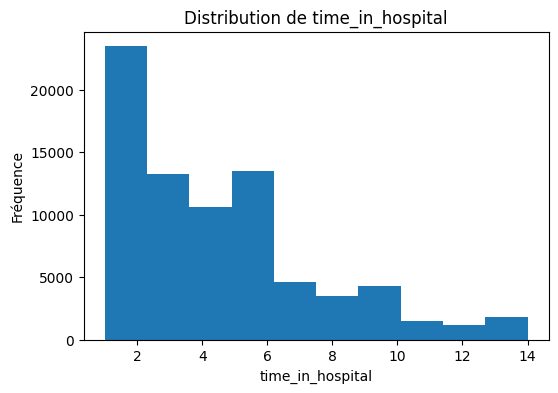

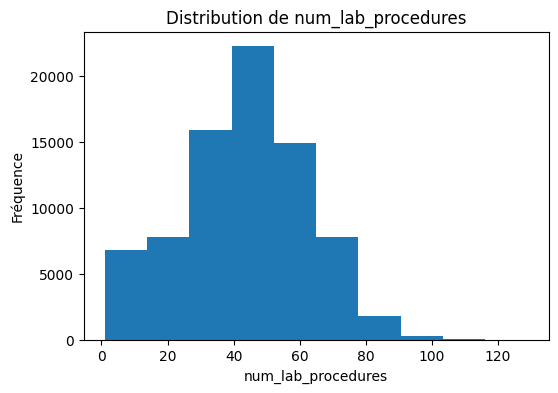

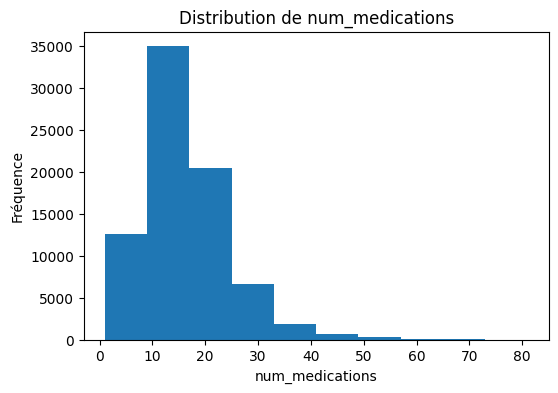

In [ ]:
# Distributions
colonnes_numeriques = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications"
]

for col in colonnes_numeriques:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col])
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

In [ ]:
#Détection des valeurs anormales ou incohérentes
print("\nVérification de certaines colonnes pour anomalies potentielles:")

print("\nValeurs de la variable age :", df["age"].unique())
print("\nValeurs de la variable gender :", df["gender"].unique())
print("\nValeurs de la variable readmitted :", df["readmitted"].unique())



Vérification de certaines colonnes pour anomalies potentielles:

Valeurs de la variable age : ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)' nan]

Valeurs de la variable gender : ['Female' 'Male' 'Unknown/Invalid' nan]

Valeurs de la variable readmitted : ['NO' '>30' '<30' nan]


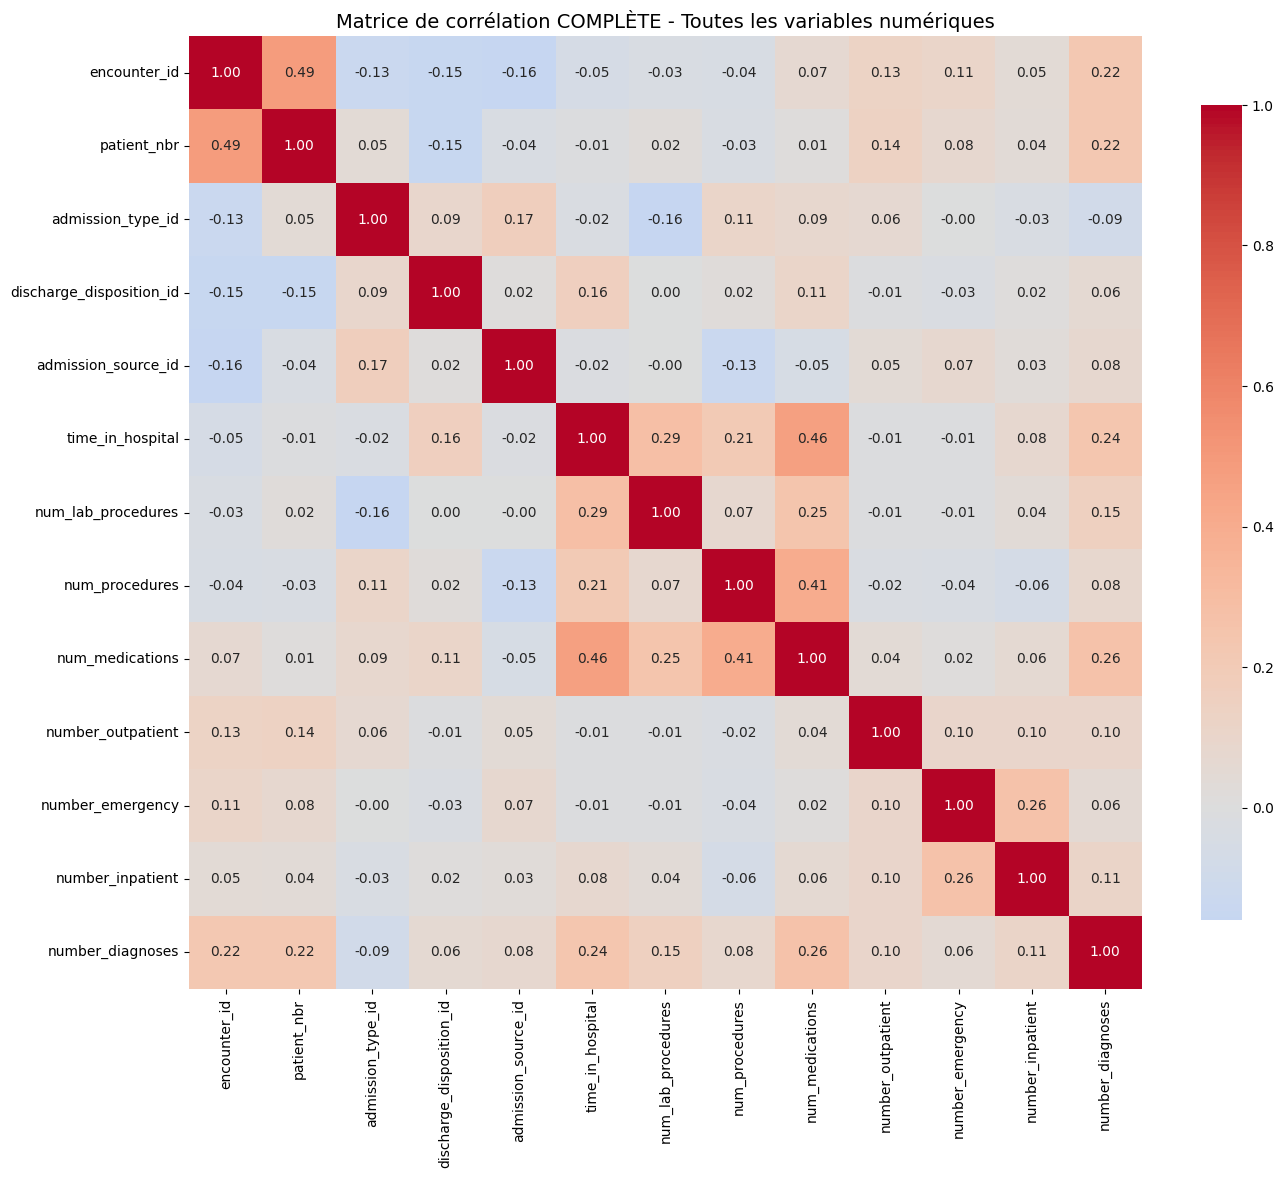

In [ ]:
import seaborn as sns

numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

# Matrice de corrélation
plt.figure(figsize=(14, 12))
correlation_matrix_complete = df[numeric_columns].corr()

sns.heatmap(correlation_matrix_complete,
            annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, cbar_kws={"shrink": .8})

plt.title("Matrice de corrélation COMPLÈTE - Toutes les variables numériques", fontsize=14)
plt.tight_layout()
plt.show()

# DATA PREPARATION

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df_copy = df.copy()


In [ ]:
# Remplacer les "?" par NaN
df_copy.replace("?", np.nan, inplace=True)

# Gestion des valeurs manquantes
categorical_cols = ['race','weight','payer_code','medical_specialty','diag_1','diag_2','diag_3','max_glu_serum','A1Cresult']
for col in categorical_cols:
    df_copy[col] = df_copy[col].fillna('Unknown')

# Supprimer les colonnes inutiles
drop_cols = ['encounter_id','patient_nbr','examide','citoglipton','glimepiride-pioglitazone',
             'metformin-rosiglitazone','metformin-pioglitazone']
df_copy.drop(columns=drop_cols, inplace=True)

# Transformer la variable cible en binaire
df_copy['readmitted_binary'] = df_copy['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Encodage des variables catégorielles
cat_cols = df_copy.select_dtypes(include=['object']).columns.tolist()
cat_cols = [col for col in cat_cols if col != 'readmitted']

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df_copy[col] = le.fit_transform(df_copy[col].astype(str))

# Créer de nouvelles variables
df_copy['previous_admissions'] = df_copy['number_outpatient'] + df_copy['number_emergency'] + df_copy['number_inpatient']
df_copy['med_per_diag'] = df_copy['num_medications'] / df_copy['number_diagnoses']

# Aperçu pour vérification
df_copy.head()


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,change,diabetesMed,readmitted,readmitted_binary,previous_admissions,med_per_diag
0,3,0,0,1,6.0,25.0,1.0,1.0,15,34,...,0,1,1,0,1,0,NO,0,0.0,1.000000
1,3,0,1,1,1.0,1.0,7.0,3.0,15,67,...,0,3,1,0,0,1,>30,0,0.0,2.000000
2,0,0,2,1,1.0,1.0,7.0,2.0,15,67,...,0,1,1,0,1,1,NO,0,3.0,2.166667
3,3,1,3,1,1.0,1.0,7.0,2.0,15,67,...,0,3,1,0,0,1,NO,0,0.0,2.285714
4,3,1,4,1,1.0,1.0,7.0,1.0,15,67,...,0,2,1,0,0,1,NO,0,0.0,1.600000


In [ ]:
df_copy['readmitted_binary'].value_counts()


,count
readmitted_binary,
0,68823
1,8776
